# Project Capstone

## Import Libraries

In [473]:
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split

## Data Wrangling

In [141]:
data = pd.read_csv("./data/data.csv")

data.head()

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,NaN
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea


In [142]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 374 entries, 0 to 373
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Person ID                374 non-null    int64  
 1   Gender                   374 non-null    object 
 2   Age                      374 non-null    int64  
 3   Occupation               374 non-null    object 
 4   Sleep Duration           374 non-null    float64
 5   Quality of Sleep         374 non-null    int64  
 6   Physical Activity Level  374 non-null    int64  
 7   Stress Level             374 non-null    int64  
 8   BMI Category             374 non-null    object 
 9   Blood Pressure           374 non-null    object 
 10  Heart Rate               374 non-null    int64  
 11  Daily Steps              374 non-null    int64  
 12  Sleep Disorder           155 non-null    object 
dtypes: float64(1), int64(7), object(5)
memory usage: 38.1+ KB


In [143]:
data.isna().sum()

Person ID                    0
Gender                       0
Age                          0
Occupation                   0
Sleep Duration               0
Quality of Sleep             0
Physical Activity Level      0
Stress Level                 0
BMI Category                 0
Blood Pressure               0
Heart Rate                   0
Daily Steps                  0
Sleep Disorder             219
dtype: int64

In [144]:
data.fillna(value="None", inplace=True)

In [145]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 374 entries, 0 to 373
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Person ID                374 non-null    int64  
 1   Gender                   374 non-null    object 
 2   Age                      374 non-null    int64  
 3   Occupation               374 non-null    object 
 4   Sleep Duration           374 non-null    float64
 5   Quality of Sleep         374 non-null    int64  
 6   Physical Activity Level  374 non-null    int64  
 7   Stress Level             374 non-null    int64  
 8   BMI Category             374 non-null    object 
 9   Blood Pressure           374 non-null    object 
 10  Heart Rate               374 non-null    int64  
 11  Daily Steps              374 non-null    int64  
 12  Sleep Disorder           374 non-null    object 
dtypes: float64(1), int64(7), object(5)
memory usage: 38.1+ KB


In [146]:
print("Jumlah duplikasi: ", data.duplicated().sum())

Jumlah duplikasi:  0


In [147]:
dataset = data.drop(columns=['Person ID', 'Occupation', 'Blood Pressure'])
dataset.head()

,Gender,Age,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Heart Rate,Daily Steps,Sleep Disorder
0,Male,27,6.1,6,42,6,Overweight,77,4200,None
1,Male,28,6.2,6,60,8,Normal,75,10000,None
2,Male,28,6.2,6,60,8,Normal,75,10000,None
3,Male,28,5.9,4,30,8,Obese,85,3000,Sleep Apnea
4,Male,28,5.9,4,30,8,Obese,85,3000,Sleep Apnea


In [148]:
dataset.describe()

,Age,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,Heart Rate,Daily Steps
count,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000
mean,42.184492,7.132086,7.312834,59.171123,5.385027,70.165775,6816.844920
std,8.673133,0.795657,1.196956,20.830804,1.774526,4.135676,1617.915679
min,27.000000,5.800000,4.000000,30.000000,3.000000,65.000000,3000.000000
25%,35.250000,6.400000,6.000000,45.000000,4.000000,68.000000,5600.000000
50%,43.000000,7.200000,7.000000,60.000000,5.000000,70.000000,7000.000000
75%,50.000000,7.800000,8.000000,75.000000,7.000000,72.000000,8000.000000
max,59.000000,8.500000,9.000000,90.000000,8.000000,86.000000,10000.000000


## Machine Learning

In [254]:
x = dataset.drop(columns=['Quality of Sleep'])
y = dataset['Quality of Sleep']

In [255]:
label_encoders = {}
for column in dataset.select_dtypes(include=['object']).columns:
    label_encoders[column] = LabelEncoder()
    dataset[column] = label_encoders[column].fit_transform(data[column])

In [ ]:
x_train, x_val, y_train, y_val = train_test_split(x, y, test_size=0.3, random_state=42)

print("Training data size:", len(x_train))
print("Validation data size:", len(x_val))

print("Training label size:", len(y_train))
print("Validation label size:", len(y_val))


Training data size: 261
Validation data size: 113
Training label size: 261
Validation label size: 113


In [ ]:
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_val_scaled = scaler.transform(x_val)

In [462]:
## Model
model = tf.keras.Sequential([
    tf.keras.Input(shape=(x_train_scaled.shape[1],)),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(1, activation='linear')
])

In [463]:
model.summary()

Model: "sequential_54"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_161 (Dense)               │ (None, 64)             │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_162 (Dense)               │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_163 (Dense)               │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,753 (10.75 KB)

 Trainable params: 2,753 (10.75 KB)

 Non-trainable params: 0 (0.00 B)

In [464]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='mean_squared_error',
    metrics=['mae']
)

In [465]:
history = model.fit(x_train_scaled, y_train,
                    epochs=500,
                    validation_data=(x_val_scaled, y_val),
                    batch_size=32,
)

Epoch 1/500
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 47.0550 - mae: 6.7231 - val_loss: 41.1392 - val_mae: 6.2327
Epoch 2/500
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 40.5871 - mae: 6.1776 - val_loss: 34.0477 - val_mae: 5.5868
Epoch 3/500
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 34.8232 - mae: 5.6326 - val_loss: 26.7222 - val_mae: 4.8387
Epoch 4/500
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 25.3418 - mae: 4.7187 - val_loss: 19.6490 - val_mae: 3.9939
Epoch 5/500
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 19.9819 - mae: 4.0137 - val_loss: 13.0381 - val_mae: 3.1234
Epoch 6/500
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 12.4380 - mae: 3.0952 - val_loss: 7.7622 - val_mae: 2.3624
Epoch 7/500
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 7.4622 - mae: 2.3864 - val_loss: 4.2504 - val_mae: 1.6965
Epoch 8/500
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 4.3030 - mae: 1.7532 - val_loss: 2.3510 - val_mae: 1.1991
Epoch 9/500
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 2.3792 - m

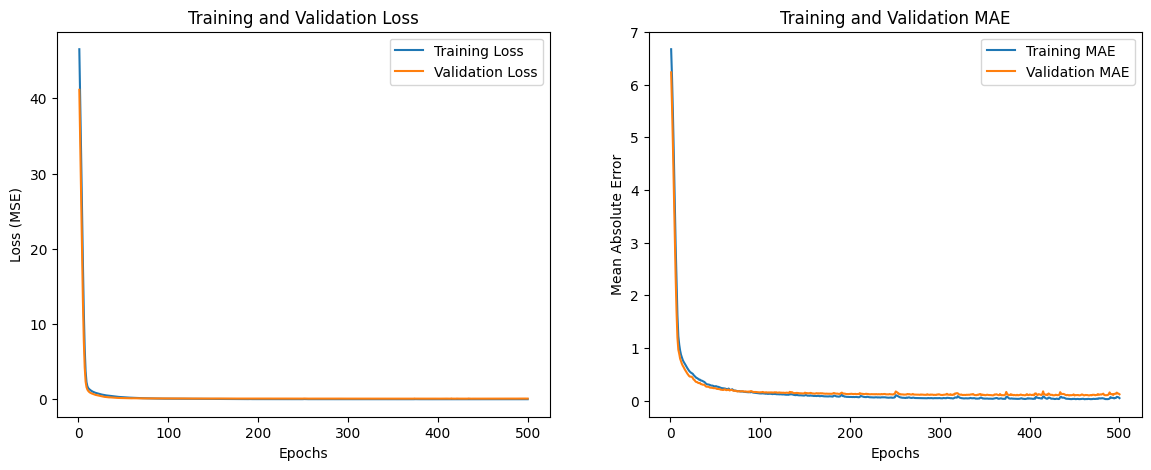

In [466]:
loss = history.history['loss']
val_loss = history.history['val_loss']
mae = history.history['mae']
val_mae = history.history['val_mae']

# Create a range for epochs
epochs = range(1, len(loss) + 1)

# Plot the loss over epochs
plt.figure(figsize=(14, 5))

# Loss plot
plt.subplot(1, 2, 1)
plt.plot(epochs, loss, label='Training Loss')
plt.plot(epochs, val_loss, label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss (MSE)')
plt.legend()

# MAE plot
plt.subplot(1, 2, 2)
plt.plot(epochs, mae, label='Training MAE')
plt.plot(epochs, val_mae, label='Validation MAE')
plt.title('Training and Validation MAE')
plt.xlabel('Epochs')
plt.ylabel('Mean Absolute Error')
plt.legend()

plt.show()

In [468]:
model.save('model2.h5')

In [467]:
predictions = model.predict(x_val_scaled)

print("Beberapa prediksi pertama pada data uji:")
print(predictions[:5])

for i in range(5):
    print(f"Prediksi: {predictions[i][0]:.2f}, Label asli: {y_val.iloc[i]:.2f}")

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
Beberapa prediksi pertama pada data uji:
[[9.092818 ]
 [5.9318976]
 [5.9936805]
 [9.092818 ]
 [5.9833465]]
Prediksi: 9.09, Label asli: 9.00
Prediksi: 5.93, Label asli: 6.00
Prediksi: 5.99, Label asli: 6.00
Prediksi: 9.09, Label asli: 9.00
Prediksi: 5.98, Label asli: 6.00


## Loaded Model

In [469]:
loaded_model = tf.keras.models.load_model('model2.h5')
loaded_model.summary()

Model: "sequential_54"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_161 (Dense)               │ (None, 64)             │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_162 (Dense)               │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_163 (Dense)               │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,755 (10.77 KB)

 Trainable params: 2,753 (10.75 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

In [471]:
predictions = loaded_model.predict(x_train_scaled)

print("Beberapa prediksi pertama pada data uji:")
print(predictions[:5])

for i in range(5):
    print(f"Prediksi: {predictions[i][0]:.2f}, Label asli: {y_train.iloc[i]:.2f}")

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
Beberapa prediksi pertama pada data uji:
[[6.966021 ]
 [8.944837 ]
 [6.03025  ]
 [7.0095983]
 [5.0426474]]
Prediksi: 6.97, Label asli: 7.00
Prediksi: 8.94, Label asli: 9.00
Prediksi: 6.03, Label asli: 6.00
Prediksi: 7.01, Label asli: 7.00
Prediksi: 5.04, Label asli: 5.00


In [ ]:
# Fungsi untuk meminta input data dari user
def get_user_input():
    inputs = []

    # Nama-nama fitur yang diharapkan
    feature_names = [
        "Gender (0 = Female, 1 = Male)",
        "Age",
        "Sleep Duration (hours)",
        "Physical Activity Level (scale 1-5)",
        "Stress Level (scale 1-5)",
        "BMI Category (0 = Underweight, 1 = Normal, 2 = Overweight, 3 = Obese)",
        "Heart Rate (bpm)",
        "Daily Steps",
        "Sleep Disorder (0 = No, 1 = Yes)"
    ]

    print("Masukkan nilai untuk setiap fitur:")
    for feature in feature_names:
        value = float(input(f"{feature}: "))
        inputs.append(value)

    # Ubah input menjadi array numpy
    inputs = np.array([inputs])  # Harus dalam bentuk 2D (1, num_features)
    return inputs

# Ambil input dari user
user_input = get_user_input()

# Lakukan prediksi
prediction = model.predict(user_input)

# Tampilkan hasil prediksi
print(f"Hasil prediksi: {prediction[0]}")

Masukkan nilai untuk setiap fitur:


ValueError: could not convert string to float: ''

: 